# Logistic Regression

## What is Logistic Regression?
Despite the name, Logistic Regression is a **classification** algorithm. It models the **probability** that an instance belongs to a class using the logistic (sigmoid) function.

**History**: Developed by David Cox in 1958. Still one of the most used classification algorithms in industry due to interpretability.

---

## 1. The Sigmoid Function

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Properties:
- Output: $(0, 1)$ interpretable as probability
- $\sigma(0) = 0.5$
- $\sigma(+\infty) \to 1$, $\sigma(-\infty) \to 0$
- Derivative: $\sigma'(z) = \sigma(z)(1 - \sigma(z))$

The model:
$$\hat{p} = h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$

---

## 2. Decision Boundary

Predict class 1 if $\hat{p} \geq 0.5$, i.e., when $\theta^T x \geq 0$

The decision boundary is the hyperplane: $\theta^T x = 0$

---

## 3. Cost Function (Log Loss / Binary Cross-Entropy)

We cannot use MSE (non-convex). Instead:

$$\text{Cost}(h_\theta(x), y) = \begin{cases} -\log(h_\theta(x)) & \text{if } y=1 \\ -\log(1-h_\theta(x)) & \text{if } y=0 \end{cases}$$

Combined:

$$J(\theta) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(h_\theta(x^{(i)})) + (1-y^{(i)})\log(1-h_\theta(x^{(i)}))\right]$$

With L2 regularization:
$$J(\theta) = -\frac{1}{m}\sum\left[y\log(h) + (1-y)\log(1-h)\right] + \frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2$$

---

## 4. Gradient Descent

The gradient (same form as linear regression!):

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m}\sum_{i=1}^{m}(h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)}$$

Matrix form: $\nabla_\theta J = \frac{1}{m} X^T(\hat{y} - y)$

Update: $\theta := \theta - \alpha \nabla_\theta J$

---

## 5. Odds and Log-Odds

$$\text{Odds} = \frac{p}{1-p}$$

$$\text{Log-Odds (Logit)} = \log\left(\frac{p}{1-p}\right) = \theta^T x$$

This is why it's called **logistic** regression it models the log-odds as a linear function.

---

## 6. Multi-class Classification

### One-vs-Rest (OvR)
Train $K$ binary classifiers, one per class. Predict class with highest probability.

### Softmax Regression (Multinomial)

$$P(y=k|x) = \frac{e^{\theta_k^T x}}{\sum_{j=1}^{K} e^{\theta_j^T x}}$$

Cross-entropy loss for multi-class:
$$J = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K} y_k^{(i)} \log(\hat{p}_k^{(i)})$$

---

## 7. Evaluation Metrics

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall (Sensitivity)} = \frac{TP}{TP + FN}$$

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

$$F_\beta = (1+\beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

**ROC-AUC**: Area under the Receiver Operating Characteristic curve (plot TPR vs FPR at all thresholds)

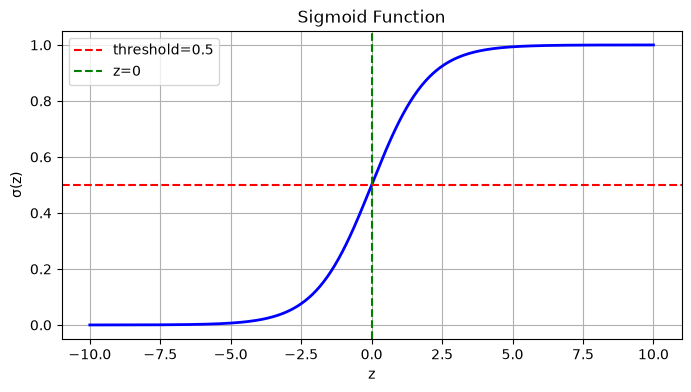

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Sigmoid function
z = np.linspace(-10, 10, 300)
sigma = 1 / (1 + np.exp(-z))

plt.figure(figsize=(8, 4))
plt.plot(z, sigma, 'b-', linewidth=2)
plt.axhline(0.5, color='r', linestyle='--', label='threshold=0.5')
plt.axvline(0, color='g', linestyle='--', label='z=0')
plt.xlabel('z'); plt.ylabel('σ(z)'); plt.title('Sigmoid Function')
plt.legend(); plt.grid(True); plt.show()

## Implementation from Scratch

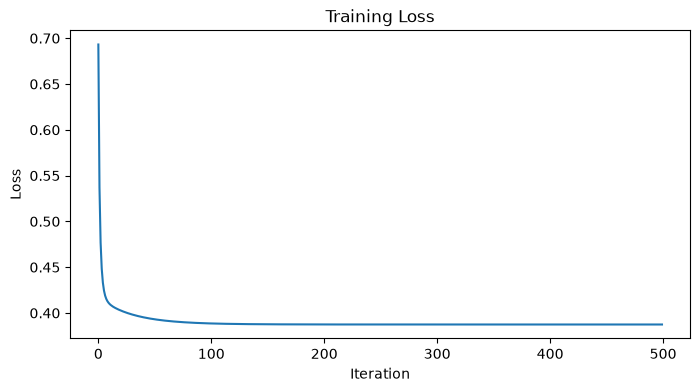

Scratch Accuracy: 0.9561


In [2]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_iter=1000, C=1.0):
        self.lr = lr
        self.n_iter = n_iter
        self.C = C  # inverse of regularization strength
        self.theta = None
        self.losses = []

    def _sigmoid(self, z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        m, n = X.shape
        self.theta = np.zeros(n + 1)
        X_b = np.c_[np.ones(m), X]

        for _ in range(self.n_iter):
            z = X_b @ self.theta
            h = self._sigmoid(z)
            # Binary cross-entropy
            loss = -np.mean(y * np.log(h + 1e-15) + (1-y) * np.log(1-h + 1e-15))
            # L2 regularization (don't penalize bias)
            reg = (1/(2*self.C)) * np.sum(self.theta[1:]**2)
            self.losses.append(loss + reg)
            grad = X_b.T @ (h - y) / m
            grad[1:] += self.theta[1:] / self.C
            self.theta -= self.lr * grad
        return self

    def predict_proba(self, X):
        X_b = np.c_[np.ones(X.shape[0]), X]
        return self._sigmoid(X_b @ self.theta)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


# Test on breast cancer dataset
X, y = load_breast_cancer(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = LogisticRegressionScratch(lr=0.1, n_iter=500)
model.fit(X_train_s, y_train)

plt.figure(figsize=(8, 4))
plt.plot(model.losses)
plt.xlabel('Iteration'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.show()

preds = model.predict(X_test_s)
accuracy = np.mean(preds == y_test)
print(f'Scratch Accuracy: {accuracy:.4f}')

## Scikit-Learn with Full Evaluation

              precision    recall  f1-score   support

   Malignant       0.98      0.95      0.96        43
      Benign       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

ROC-AUC: 0.9974


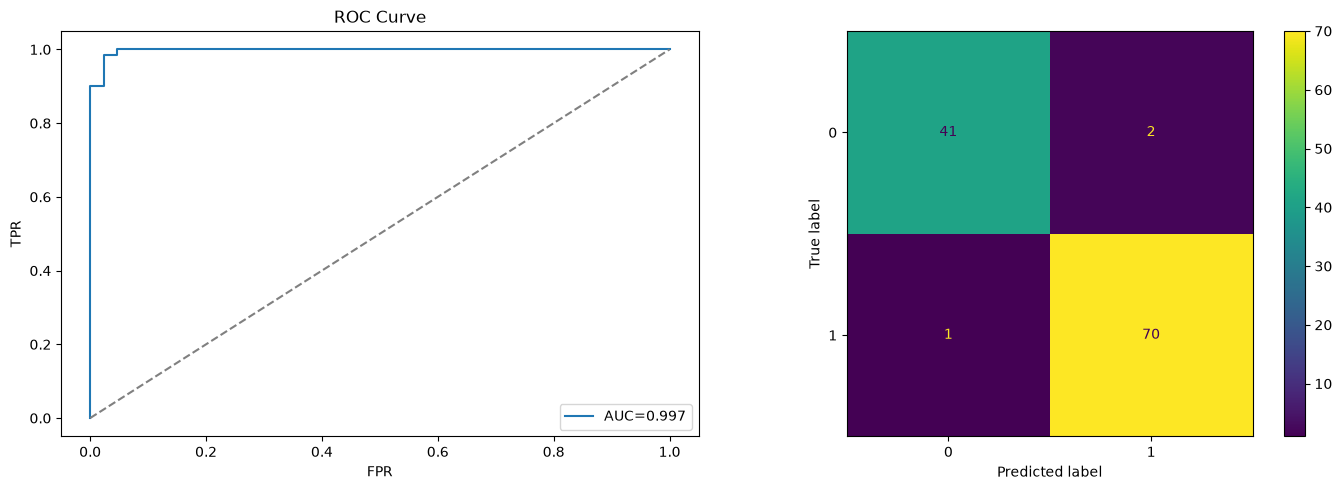

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay
)

sk_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
sk_model.fit(X_train_s, y_train)
sk_preds = sk_model.predict(X_test_s)
sk_proba = sk_model.predict_proba(X_test_s)[:, 1]

print(classification_report(y_test, sk_preds, target_names=['Malignant', 'Benign']))
print(f'ROC-AUC: {roc_auc_score(y_test, sk_proba):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, sk_proba)
axes[0].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, sk_proba):.3f}')
axes[0].plot([0,1],[0,1],'--', color='gray')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC Curve')
axes[0].legend()

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, sk_preds, ax=axes[1])
plt.tight_layout(); plt.show()

## Precision-Recall Curve

The ROC curve can be overly optimistic when the dataset is imbalanced (many more negatives than positives). In that situation, a large number of true negatives inflates the True Positive Rate without making the classifier practically useful on the minority class.

The Precision-Recall (PR) curve focuses only on the positive class:
- **Precision** (y-axis), of all predicted positives, how many are correct?
- **Recall** (x-axis), of all actual positives, how many did we catch?

Use the PR curve when:
- The positive class is rare (fraud detection, disease diagnosis, anomaly detection)
- False positives and false negatives have very different costs
- You care more about performance on the minority class than overall accuracy

**Average Precision (AP)** summarises the PR curve as a single number (weighted mean of precisions at each threshold).

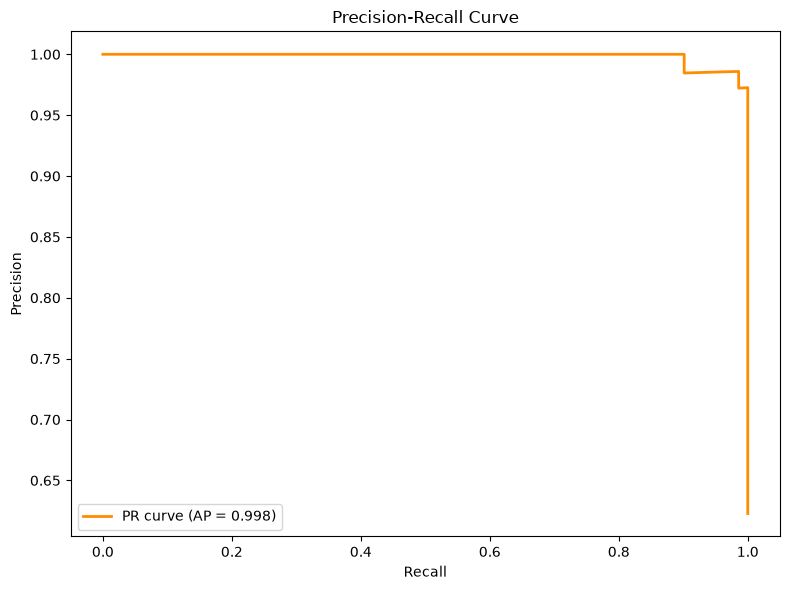

In [4]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# y_prob reuses sk_proba computed in the cell above
y_prob = sk_proba

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'PR curve (AP = {ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.show()

## Threshold Tuning

The default decision threshold of 0.5 is rarely optimal. Adjusting it lets you trade off Precision against Recall depending on the cost of each type of error:

- **Raise the threshold**, fewer positive predictions, higher Precision, lower Recall (useful when false positives are expensive, e.g. spam filters)
- **Lower the threshold**, more positive predictions, lower Precision, higher Recall (useful when false negatives are expensive, e.g. cancer screening)

The F1 score captures the harmonic mean of Precision and Recall and peaks at the threshold that balances the two.

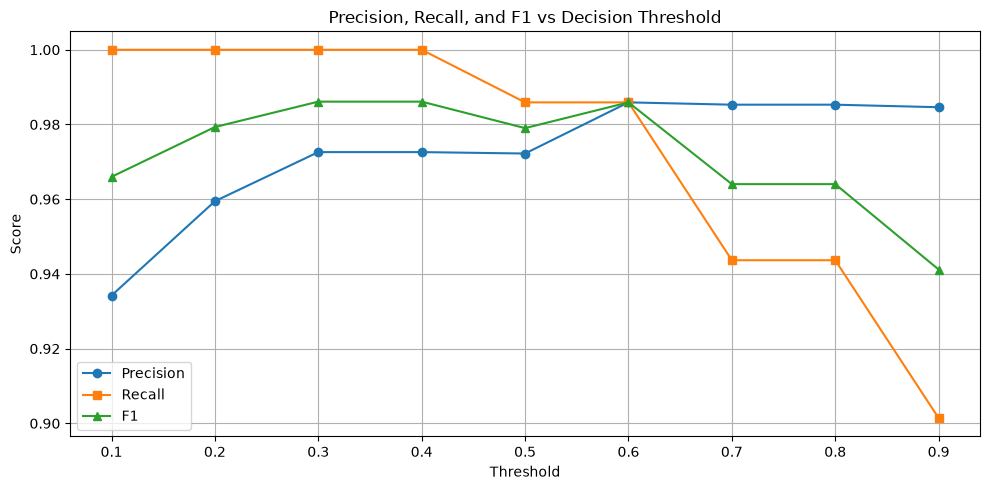

In [5]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds_range = np.arange(0.1, 0.91, 0.1)
precisions, recalls, f1s = [], [], []

for t in thresholds_range:
    preds = (y_prob >= t).astype(int)
    precisions.append(precision_score(y_test, preds, zero_division=0))
    recalls.append(recall_score(y_test, preds))
    f1s.append(f1_score(y_test, preds, zero_division=0))

plt.figure(figsize=(10, 5))
plt.plot(thresholds_range, precisions, marker='o', label='Precision')
plt.plot(thresholds_range, recalls, marker='s', label='Recall')
plt.plot(thresholds_range, f1s, marker='^', label='F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, and F1 vs Decision Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Class Imbalance: Effect of `class_weight`

When one class vastly outnumbers another, a classifier can achieve high accuracy by always predicting the majority class, yet completely miss the minority class.

Setting `class_weight='balanced'` tells scikit-learn to upweight the minority class inversely proportional to its frequency, penalising misclassifications of rare positives more heavily during training.

In [6]:
# Create an imbalanced dataset by dropping 80% of the positive class
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]
rng = np.random.default_rng(42)
drop_pos = rng.choice(pos_idx, size=int(len(pos_idx) * 0.8), replace=False)
keep_idx = np.concatenate([neg_idx, np.setdiff1d(pos_idx, drop_pos)])
X_imb, y_imb = X[keep_idx], y[keep_idx]
print(f'Class distribution, 0: {(y_imb==0).sum()}, 1: {(y_imb==1).sum()}')

X_tr_i, X_te_i, y_tr_i, y_te_i = train_test_split(
    X_imb, y_imb, test_size=0.2, random_state=42, stratify=y_imb
)
scaler_i = StandardScaler()
X_tr_is = scaler_i.fit_transform(X_tr_i)
X_te_is = scaler_i.transform(X_te_i)

# Without class_weight
lr_plain = LogisticRegression(max_iter=1000, random_state=42)
lr_plain.fit(X_tr_is, y_tr_i)
preds_plain = lr_plain.predict(X_te_is)

# With class_weight='balanced'
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_tr_is, y_tr_i)
preds_balanced = lr_balanced.predict(X_te_is)

from sklearn.metrics import classification_report
print('Without class_weight:')
print(classification_report(y_te_i, preds_plain, target_names=['Malignant', 'Benign']))

print('With class_weight="balanced":')
print(classification_report(y_te_i, preds_balanced, target_names=['Malignant', 'Benign']))

Class distribution, 0: 212, 1: 72


Without class_weight:
              precision    recall  f1-score   support

   Malignant       1.00      0.98      0.99        43
      Benign       0.93      1.00      0.97        14

    accuracy                           0.98        57
   macro avg       0.97      0.99      0.98        57
weighted avg       0.98      0.98      0.98        57

With class_weight="balanced":
              precision    recall  f1-score   support

   Malignant       1.00      0.98      0.99        43
      Benign       0.93      1.00      0.97        14

    accuracy                           0.98        57
   macro avg       0.97      0.99      0.98        57
weighted avg       0.98      0.98      0.98        57



## Softmax / Multiclass

In [7]:
X_iris, y_iris = load_iris(return_X_y=True)
X_tr, X_te, y_tr, y_te = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)
scaler2 = StandardScaler()
X_tr_s = scaler2.fit_transform(X_tr)
X_te_s = scaler2.transform(X_te)

# OvR (sklearn>=1.7 removed multi_class; wrap for explicit one-vs-rest)
from sklearn.multiclass import OneVsRestClassifier
ovr = OneVsRestClassifier(LogisticRegression(max_iter=1000))
ovr.fit(X_tr_s, y_tr)

# Multinomial (Softmax) now the default multiclass strategy
softmax = LogisticRegression(solver='lbfgs', max_iter=1000)
softmax.fit(X_tr_s, y_tr)

print(f'OvR Accuracy:       {ovr.score(X_te_s, y_te):.4f}')
print(f'Softmax Accuracy:   {softmax.score(X_te_s, y_te):.4f}')

OvR Accuracy:       0.9667
Softmax Accuracy:   1.0000


In [8]:
from sklearn.metrics import classification_report

# Use the softmax model predictions on the held-out iris test set
y_test_multi = y_te
y_pred_multi = softmax.predict(X_te_s)

print(classification_report(
    y_test_multi, y_pred_multi,
    target_names=['setosa', 'versicolor', 'virginica']
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Averaging Strategies for Multi-Class Metrics

When there are more than two classes, precision, recall, and F1 can be aggregated across classes in three ways:

| Strategy | How it works | When to use |
|---|---|---|
| **macro** | Compute metric for each class independently, then take the unweighted mean | All classes equally important regardless of size |
| **micro** | Aggregate all TP / FP / FN across classes before computing the metric | Global performance; dominated by the largest class |
| **weighted** | Compute metric per class, then take the mean weighted by each class's support (number of true instances) | Accounts for class imbalance while still reporting per-class information |

For balanced datasets the three averages are nearly identical. For imbalanced datasets they can diverge significantly, micro-average will reflect the majority class, while macro-average highlights poor performance on small classes.

## Learning Curves

A learning curve plots model performance against the amount of training data used. It is the primary diagnostic for distinguishing underfitting from overfitting:

- **High bias (underfitting):** Both training and validation scores are low and converge to a similar low value. Adding more data will not help much; the model needs more complexity.
- **High variance (overfitting):** Training score is high but validation score is much lower, with a large gap between the two curves. Adding more data may help close the gap.
- **Good fit:** Training and validation curves converge to a similarly high score as training size grows.

/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


...

/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/home/dell/Desktop/AI_Tasks/Additional_Data/zero-to-ai-engineer/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


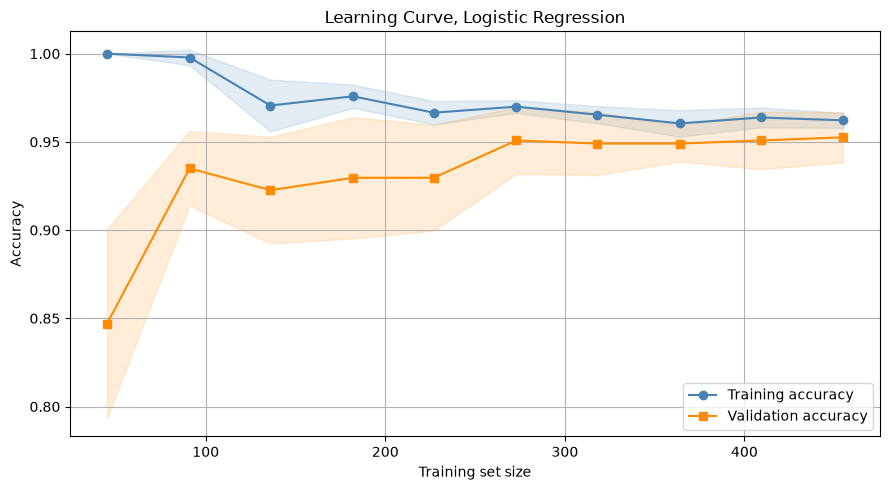

In [9]:
from sklearn.model_selection import learning_curve, StratifiedKFold

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(max_iter=1000), X, y,
    cv=StratifiedKFold(5),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Training accuracy')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                 alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 's-', color='darkorange', label='Validation accuracy')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                 alpha=0.15, color='darkorange')
plt.xlabel('Training set size')
plt.ylabel('Accuracy')
plt.title('Learning Curve, Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

## Additional Learning Resources

### Papers & Books
- 📄 [The Analysis of Binary Data](https://www.taylorfrancis.com/books/mono/10.1201/9781315137995/analysis-binary-data-cox-snell) Cox & Snell (original logistic regression work)
- 📖 [ESL Chapter 4](https://web.stanford.edu/~hastie/ElemStatLearn/) Linear Methods for Classification
- 📖 [ISLR Chapter 4](https://www.statlearning.com/) Classification

### Courses & Videos
- 🎥 [Andrew Ng CS229: Logistic Regression](https://cs229.stanford.edu/)
- 🎥 [StatQuest: Logistic Regression](https://www.youtube.com/watch?v=yIYKR4sgzI8)
- 🎥 [StatQuest: ROC and AUC](https://www.youtube.com/watch?v=4jRBRDbJemM)

### Documentation
- 📚 [Scikit-Learn: Logistic Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- 📚 [Scikit-Learn: Classification Metrics](https://scikit-learn.org/stable/modules/model_evaluation.html)